# KNN Recommendation Model — Loom Web
**Đề tài Final Assignment #7 — Integrate ML model to Web app**

Dataset: Myntra Products Catalog (~12.491 sản phẩm), lọc lấy nhóm túi/phụ kiện (~476 dòng).  
Model: `NearestNeighbors` (Scikit-learn) — gợi ý túi dựa trên giá, loại túi, màu sắc.

---
## Cell 1 — Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import joblib
import os

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Đọc dataset gốc
df_raw = pd.read_csv('../data/raw_products.csv')

print('=== Cấu trúc dataset gốc ===')
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
print()
df_raw.head(3)

=== Cấu trúc dataset gốc ===
Shape: (12491, 8)
Columns: ['ProductID', 'ProductName', 'ProductBrand', 'Gender', 'Price (INR)', 'NumImages', 'Description', 'PrimaryColor']



,ProductID,ProductName,ProductBrand,Gender,Price (INR),NumImages,Description,PrimaryColor
0,10017413,DKNY Unisex Black & Grey Printed Medium Trolle...,DKNY,Unisex,11745,7,"Black and grey printed medium trolley bag, sec...",Black
1,10016283,EthnoVogue Women Beige & Grey Made to Measure ...,EthnoVogue,Women,5810,7,Beige & Grey made to measure kurta with churid...,Beige
2,10009781,SPYKAR Women Pink Alexa Super Skinny Fit High-...,SPYKAR,Women,899,7,Pink coloured wash 5-pocket high-rise cropped ...,Pink


---
## Cell 2 — Tiền xử lý & Feature Engineering

Dataset Myntra không có cột `category` sẵn và cột `PrimaryColor` có khoảng trắng thừa.  
Ba bước bắt buộc:
1. **Lọc nhóm túi/phụ kiện** từ `ProductName`.
2. **Làm sạch `PrimaryColor`** — `.str.strip()` và loại dòng thiếu màu.
3. **Tạo cột `category`** bằng rule-based keyword matching từ `ProductName`.

In [3]:
# ── BƯỚC 1: Lọc nhóm túi/phụ kiện ──────────────────────────────────────────
BAG_KEYWORDS = [
    'bag', 'backpack', 'handbag', 'trolley', 'clutch',
    'wallet', 'purse', 'luggage', 'duffel', 'sling', 'tote'
]

pattern = '|'.join(BAG_KEYWORDS)
mask = df_raw['ProductName'].str.contains(pattern, case=False, na=False)
df = df_raw[mask].copy()
df.reset_index(drop=True, inplace=True)

print(f'Dataset gốc: {len(df_raw):,} dòng')
print(f'Sau khi lọc túi/phụ kiện: {len(df):,} dòng')
print()

# ── BƯỚC 2: Làm sạch PrimaryColor ────────────────────────────────────────────
# Cột PrimaryColor có khoảng trắng đầu (vd ' Black') → strip
df['PrimaryColor'] = df['PrimaryColor'].str.strip()

before = len(df)
df = df[df['PrimaryColor'].notna() & (df['PrimaryColor'] != '')].copy()
after = len(df)
print(f'Đã loại {before - after} dòng thiếu PrimaryColor')
print(f'Dòng còn lại: {after:,}')
print()

# ── BƯỚC 3: Tạo cột category từ ProductName ──────────────────────────────────
def assign_category(name: str) -> str:
    n = name.lower()
    if 'trolley' in n or 'luggage' in n:
        return 'Trolley/Luggage'
    if 'backpack' in n:
        return 'Backpack'
    if 'clutch' in n:
        return 'Clutch'
    if 'wallet' in n or 'purse' in n:
        return 'Wallet'
    if 'sling' in n or 'duffel' in n:
        return 'Sling'
    if 'tote' in n:
        return 'Tote'
    if 'handbag' in n or 'bag' in n:
        return 'Handbag'
    return 'Other'

df['category'] = df['ProductName'].apply(assign_category)

# Đổi tên cột Price, quy đổi INR → VND (1 INR ≈ 300 VND), làm tròn đến nghìn đồng
df.rename(columns={'Price (INR)': 'price', 'PrimaryColor': 'color'}, inplace=True)
INR_TO_VND = 300
df['price'] = (df['price'] * INR_TO_VND).round(-3).astype(int)

print('Phân bố category:')
print(df['category'].value_counts())
print()
print('Mẫu 5 dòng sau tiền xử lý:')
df[['ProductName', 'price', 'color', 'category']].head(5)

Dataset gốc: 12,491 dòng
Sau khi lọc túi/phụ kiện: 476 dòng

Đã loại 6 dòng thiếu PrimaryColor
Dòng còn lại: 470

Phân bố category:
category
Handbag            182
Backpack           101
Sling               73
Wallet              64
Trolley/Luggage     42
Clutch               8
Name: count, dtype: int64

Mẫu 5 dòng sau tiền xử lý:


,ProductName,price,color,category
0,DKNY Unisex Black & Grey Printed Medium Trolle...,3524000,Black,Trolley/Luggage
1,DKNY Unisex Black Large Trolley Bag,5208000,Black,Trolley/Luggage
2,Kenneth Cole Women Navy Blue Solid Backpack,739000,Blue,Backpack
3,DKNY Unisex Black Medium Trolley Bag,3996000,Black,Trolley/Luggage
4,DKNY Unisex Gold & White Printed Cabin Trolley...,4320000,White,Trolley/Luggage


---
## Cell 3 — EDA + Biểu đồ

Tạo 4 biểu đồ phân tích dữ liệu, lưu vào `notebooks/figures/`.

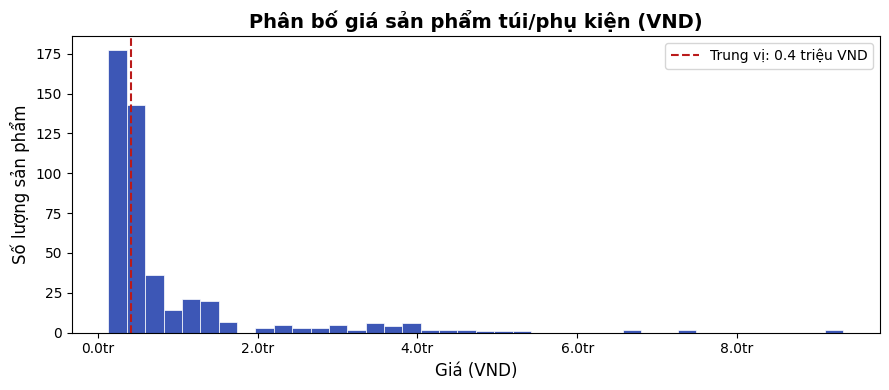

Saved: figures/01_price_distribution.png


In [4]:
os.makedirs('figures', exist_ok=True)

# ── Biểu đồ 1: Histogram phân bố giá ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['price'], bins=40, color='#3d57b6', edgecolor='white', linewidth=0.5)
ax.set_title('Phân bố giá sản phẩm túi/phụ kiện (VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Giá (VND)', fontsize=12)
ax.set_ylabel('Số lượng sản phẩm', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}tr'))
ax.axvline(df['price'].median(), color='#ba1a1a', linestyle='--',
           label=f"Trung vị: {df['price'].median()/1e6:.1f} triệu VND")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/01_price_distribution.png', dpi=150)
plt.show()
print('Saved: figures/01_price_distribution.png')

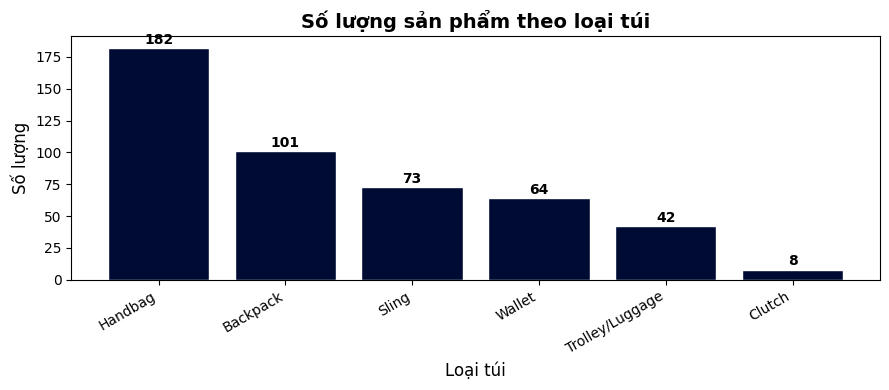

Saved: figures/02_category_distribution.png


In [5]:
# ── Biểu đồ 2: Bar chart số lượng sản phẩm theo category ────────────────────
cat_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cat_counts.index, cat_counts.values, color='#000b34', edgecolor='white')
ax.set_title('Số lượng sản phẩm theo loại túi', fontsize=14, fontweight='bold')
ax.set_xlabel('Loại túi', fontsize=12)
ax.set_ylabel('Số lượng', fontsize=12)
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/02_category_distribution.png', dpi=150)
plt.show()
print('Saved: figures/02_category_distribution.png')

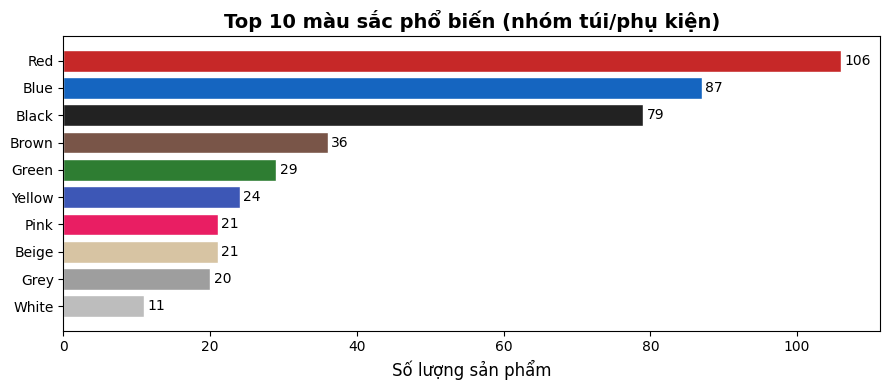

Saved: figures/03_top_colors.png


In [6]:
# ── Biểu đồ 3: Top 10 màu phổ biến ──────────────────────────────────────────
top_colors = df['color'].value_counts().head(10)

COLOR_MAP = {
    'Black': '#222222', 'Brown': '#795548', 'Blue': '#1565c0',
    'Beige': '#d7c4a3', 'Grey': '#9e9e9e', 'Red': '#c62828',
    'Green': '#2e7d32', 'Pink': '#e91e63', 'White': '#bdbdbd',
    'Gold': '#f9a825'
}
bar_colors = [COLOR_MAP.get(c, '#3d57b6') for c in top_colors.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(top_colors.index[::-1], top_colors.values[::-1],
               color=bar_colors[::-1], edgecolor='white')
ax.set_title('Top 10 màu sắc phổ biến (nhóm túi/phụ kiện)', fontsize=14, fontweight='bold')
ax.set_xlabel('Số lượng sản phẩm', fontsize=12)
for bar, val in zip(bars, top_colors.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('figures/03_top_colors.png', dpi=150)
plt.show()
print('Saved: figures/03_top_colors.png')

C:\Users\PV\AppData\Local\Temp\ipykernel_5028\3934157525.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=order, patch_artist=True,


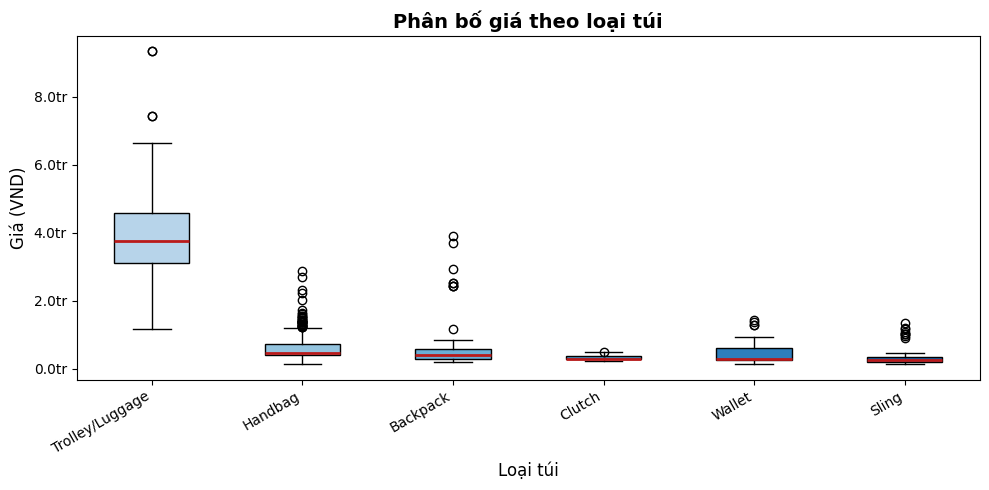

Saved: figures/04_price_by_category_boxplot.png


In [7]:
# ── Biểu đồ 4: Boxplot giá theo category ─────────────────────────────────────
order = df.groupby('category')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
data_by_cat = [df[df['category'] == c]['price'].values for c in order]
bp = ax.boxplot(data_by_cat, labels=order, patch_artist=True,
                medianprops=dict(color='#ba1a1a', linewidth=2))
colors_box = plt.cm.Blues(np.linspace(0.3, 0.8, len(order)))
for patch, col in zip(bp['boxes'], colors_box):
    patch.set_facecolor(col)
ax.set_title('Phân bố giá theo loại túi', fontsize=14, fontweight='bold')
ax.set_xlabel('Loại túi', fontsize=12)
ax.set_ylabel('Giá (VND)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}tr'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figures/04_price_by_category_boxplot.png', dpi=150)
plt.show()
print('Saved: figures/04_price_by_category_boxplot.png')

---
## Cell 4 — Tiền xử lý cho Model (ColumnTransformer)

### Tại sao phải chuẩn hóa dữ liệu?

kNN tính khoảng cách **Euclidean** giữa các điểm dữ liệu:
$$d(x, y) = \sqrt{\sum_{i}(x_i - y_i)^2}$$

Nếu **không chuẩn hóa**, cột `price` có giá trị từ vài trăm nghìn đến hàng chục triệu VND sẽ **lấn át** hoàn toàn các đặc trưng OneHot (0/1). Model khi đó chỉ gợi ý theo giá, bỏ qua loại túi và màu sắc.

**`StandardScaler`** đưa `price` về phân phối chuẩn (mean=0, std=1), cân bằng tầm ảnh hưởng với các cột OneHot.

In [8]:
# Chuẩn bị features
features = df[['price', 'category', 'color']].copy()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['price']),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['category', 'color']),
    ]
)

X = preprocessor.fit_transform(features)

print(f'Shape trước transform : {features.shape}')
print(f'Shape sau  transform  : {X.shape}')
print(f'  - 1 cột price (scaled)')
cat_cats = preprocessor.named_transformers_['cat'].categories_
print(f'  - {len(cat_cats[0])} dummy category: {list(cat_cats[0])}')
print(f'  - {len(cat_cats[1])} dummy color')

Shape trước transform : (470, 3)
Shape sau  transform  : (470, 22)
  - 1 cột price (scaled)
  - 6 dummy category: ['Backpack', 'Clutch', 'Handbag', 'Sling', 'Trolley/Luggage', 'Wallet']
  - 15 dummy color


---
## Cell 5 — Chọn k (minh họa khoảng cách trung bình)

Thử các giá trị k = 3, 5, 7, 9 và vẽ khoảng cách trung bình tới k hàng xóm gần nhất.  
k quá nhỏ → overfitting (gợi ý quá hẹp), k quá lớn → underfitting (gợi ý không liên quan).

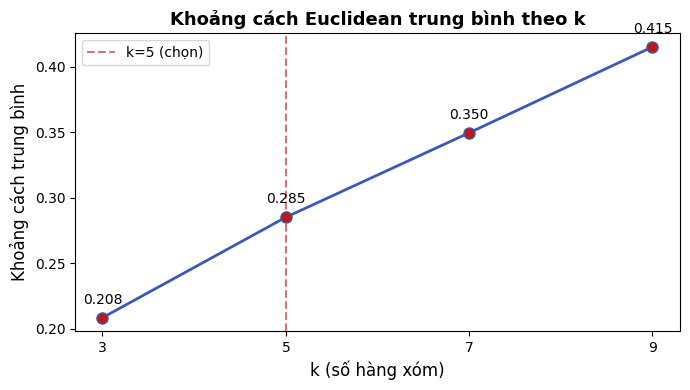

Saved: figures/05_k_selection.png

  k=3: mean dist = 0.2085
  k=5: mean dist = 0.2852
  k=7: mean dist = 0.3496
  k=9: mean dist = 0.4153


In [9]:
k_values = [3, 5, 7, 9]
mean_dists = []

for k in k_values:
    knn_tmp = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
    knn_tmp.fit(X)
    distances, _ = knn_tmp.kneighbors(X)
    # bỏ cột 0 (khoảng cách tới chính nó = 0)
    mean_dists.append(distances[:, 1:].mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, mean_dists, marker='o', color='#3d57b6',
        linewidth=2, markersize=8, markerfacecolor='#ba1a1a')
for k, d in zip(k_values, mean_dists):
    ax.annotate(f'{d:.3f}', (k, d), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10)
ax.set_title('Khoảng cách Euclidean trung bình theo k', fontsize=13, fontweight='bold')
ax.set_xlabel('k (số hàng xóm)', fontsize=12)
ax.set_ylabel('Khoảng cách trung bình', fontsize=12)
ax.set_xticks(k_values)
ax.axvline(5, color='#ba1a1a', linestyle='--', alpha=0.6, label='k=5 (chọn)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/05_k_selection.png', dpi=150)
plt.show()
print('Saved: figures/05_k_selection.png')
print()
for k, d in zip(k_values, mean_dists):
    print(f'  k={k}: mean dist = {d:.4f}')

**Lý do chọn k = 5:**  
Khoảng cách tăng dần khi k lớn (model thu nạp thêm hàng xóm xa hơn), nhưng tốc độ tăng chậm lại sau k=5.  
k=5 cân bằng giữa **độ đa dạng gợi ý** (không quá giống nhau) và **độ liên quan** (không kéo những sản phẩm quá khác).  
Thực tế chatbot trả về 5 kết quả → k=5 là lựa chọn tự nhiên.

---
## Cell 6 — Train Model

In [10]:
# n_neighbors=6: 5 gợi ý thật + 1 (chính sản phẩm query, sẽ bị loại bỏ)
model = NearestNeighbors(n_neighbors=6, metric='euclidean')
model.fit(X)

print('Model đã train xong.')
print(f'  n_neighbors : {model.n_neighbors}')
print(f'  metric      : {model.metric}')
print(f'  Số điểm fit : {model.n_samples_fit_}')
print(f'  Feature dim : {X.shape[1]}')

Model đã train xong.
  n_neighbors : 6
  metric      : euclidean
  Số điểm fit : 470
  Feature dim : 22


---
## Cell 6b — Đánh giá model (Train/Test Split 80/20)

Chia dữ liệu thành **80% train / 20% test**, train KNN trên tập train, đánh giá trên tập test bằng:
- **Category Accuracy** — dự đoán loại túi bằng majority vote của k hàng xóm gần nhất.
- **Price RMSE** — dự đoán giá bằng trung bình k hàng xóm, đo sai số trung bình.

Tap train: 376 mau (80%)
Tap test : 94  mau (20%)

=== KET QUA DANH GIA ===
Category Accuracy : 100.0%
Price RMSE        : 280,208 VND  (34.0% cua gia trung binh)
R2 Score (gia)    : 0.914  (91.4%)


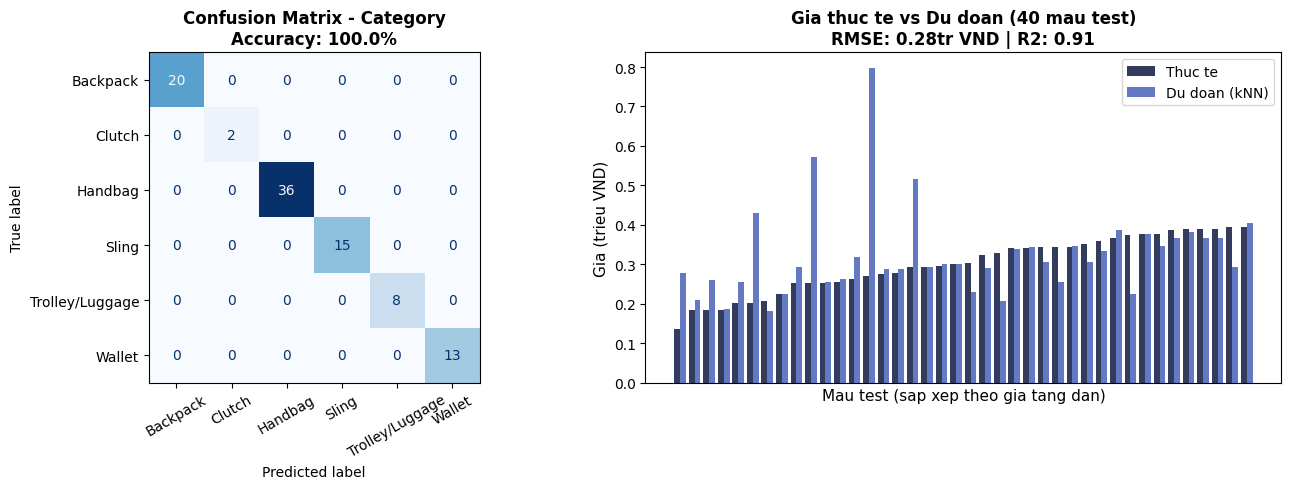

Saved: figures/07_evaluation.png

=== Accuracy theo loai tui ===
  Backpack          : 100%  (20 mau test)
  Clutch            : 100%  (2 mau test)
  Handbag           : 100%  (36 mau test)
  Sling             : 100%  (15 mau test)
  Trolley/Luggage   : 100%  (8 mau test)
  Wallet            : 100%  (13 mau test)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, ConfusionMatrixDisplay, confusion_matrix

# scipy.stats.mode không hỗ trợ string từ v1.11 → dùng np.unique thay thế
def majority_vote(arr):
    values, counts = np.unique(arr, return_counts=True)
    return values[np.argmax(counts)]

# ── Split 80/20 (stratify giữ đúng tỷ lệ category) ──────────────────────────
idx_all = np.arange(len(df))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=df['category']
)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

print(f'Tap train: {len(df_train)} mau ({len(df_train)/len(df)*100:.0f}%)')
print(f'Tap test : {len(df_test)}  mau ({len(df_test)/len(df)*100:.0f}%)')

# ── Fit preprocessor RIÊNG trên tập train (tránh data leakage) ───────────────
prep_eval = ColumnTransformer([
    ('num', StandardScaler(), ['price']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['category', 'color']),
])
X_train_eval = prep_eval.fit_transform(df_train[['price', 'category', 'color']])
X_test_eval  = prep_eval.transform(df_test[['price', 'category', 'color']])

# ── Train KNN trên 80% ────────────────────────────────────────────────────────
knn_eval = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_eval.fit(X_train_eval)

_, nn_idxs = knn_eval.kneighbors(X_test_eval, n_neighbors=5)

# ── Category Accuracy (majority vote) ────────────────────────────────────────
cat_train_arr = df_train['category'].values
cat_test_arr  = df_test['category'].values

cat_pred = np.array([majority_vote(cat_train_arr[idxs]) for idxs in nn_idxs])

cat_accuracy = accuracy_score(cat_test_arr, cat_pred)

# ── Price RMSE ────────────────────────────────────────────────────────────────
price_train_arr = df_train['price'].values
price_test_arr  = df_test['price'].values
price_pred      = np.array([price_train_arr[idxs].mean() for idxs in nn_idxs])

rmse     = np.sqrt(mean_squared_error(price_test_arr, price_pred))
rmse_pct = rmse / price_test_arr.mean() * 100
ss_res   = np.sum((price_test_arr - price_pred) ** 2)
ss_tot   = np.sum((price_test_arr - price_test_arr.mean()) ** 2)
r2       = 1 - ss_res / ss_tot

print(f'\n=== KET QUA DANH GIA ===')
print(f'Category Accuracy : {cat_accuracy*100:.1f}%')
print(f'Price RMSE        : {rmse:,.0f} VND  ({rmse_pct:.1f}% cua gia trung binh)')
print(f'R2 Score (gia)    : {r2:.3f}  ({r2*100:.1f}%)')

# ── Biểu đồ: Confusion Matrix + Price chart ──────────────────────────────────
labels = sorted(df['category'].unique())
cm     = confusion_matrix(cat_test_arr, cat_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix - Category\nAccuracy: {cat_accuracy*100:.1f}%',
                  fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sort_idx = np.argsort(price_test_arr)
n_show   = min(40, len(price_test_arr))
s_idx    = sort_idx[:n_show]
x_pos    = np.arange(n_show)
axes[1].bar(x_pos - 0.2, price_test_arr[s_idx] / 1e6, 0.4,
            label='Thuc te', color='#000b34', alpha=0.8)
axes[1].bar(x_pos + 0.2, price_pred[s_idx] / 1e6, 0.4,
            label='Du doan (kNN)', color='#3d57b6', alpha=0.8)
axes[1].set_title(f'Gia thuc te vs Du doan ({n_show} mau test)\nRMSE: {rmse/1e6:.2f}tr VND | R2: {r2:.2f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mau test (sap xep theo gia tang dan)', fontsize=11)
axes[1].set_ylabel('Gia (trieu VND)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('figures/07_evaluation.png', dpi=150)
plt.show()
print('Saved: figures/07_evaluation.png')

print('\n=== Accuracy theo loai tui ===')
for cat in labels:
    mask = cat_test_arr == cat
    if mask.sum() == 0:
        continue
    acc_c = accuracy_score(cat_test_arr[mask], cat_pred[mask])
    print(f'  {cat:<18}: {acc_c*100:.0f}%  ({mask.sum()} mau test)')

---
## Cell 7 — Demo gợi ý + Scatter PCA 2D

In [12]:
# Lấy 1 sản phẩm mẫu và tìm 5 túi gần nhất
QUERY_IDX = 0  # DKNY Trolley Black
query_vec = X[QUERY_IDX].reshape(1, -1)

distances, indices = model.kneighbors(query_vec)
# bỏ kết quả đầu tiên (chính nó, dist=0)
neighbor_indices = indices[0][1:]
neighbor_dists   = distances[0][1:]

q = df.iloc[QUERY_IDX]
print(f'Sản phẩm query: [{QUERY_IDX}] {q["ProductName"]}')
print(f'  Giá: {q["price"]:,} VND  |  Category: {q["category"]}  |  Color: {q["color"]}')
print()
print('5 sản phẩm gợi ý gần nhất:')
print('-' * 80)

results = []
for rank, (idx, dist) in enumerate(zip(neighbor_indices, neighbor_dists), 1):
    row = df.iloc[idx]
    results.append({
        'Rank': rank,
        'Tên sản phẩm': row['ProductName'][:55],
        'Giá (VND)': f"{row['price']:,}",
        'Category': row['category'],
        'Màu': row['color'],
        'Khoảng cách': round(dist, 4)
    })

pd.set_option('display.max_colwidth', 60)
pd.DataFrame(results).set_index('Rank')

Sản phẩm query: [0] DKNY Unisex Black & Grey Printed Medium Trolley Bag
  Giá: 3,524,000 VND  |  Category: Trolley/Luggage  |  Color: Black

5 sản phẩm gợi ý gần nhất:
--------------------------------------------------------------------------------


,Tên sản phẩm,Giá (VND),Category,Màu,Khoảng cách
Rank,,,,,
1,Calvin Klein Unisex Black & White Printed Cabin Trolley,"3,510,000",Trolley/Luggage,Black,0.0112
2,Calvin Klein Unisex Black Large Trolley Bag,"3,564,000",Trolley/Luggage,Black,0.0321
3,DKNY Unisex Black Medium Trolley Bag,"3,712,000",Trolley/Luggage,Black,0.1510
4,Calvin Klein Unisex Black & White Printed Large Trolley,"3,807,000",Trolley/Luggage,Black,0.2272
5,DKNY Unisex Black & Grey Printed Cabin Trolley Bag,"3,240,000",Trolley/Luggage,Black,0.2280


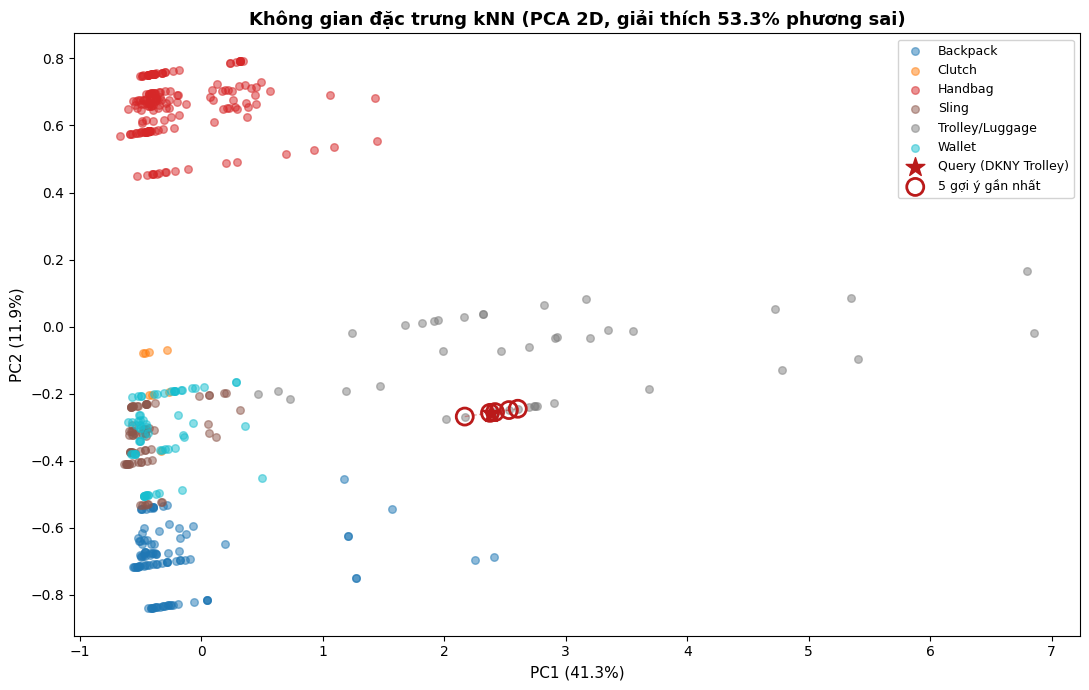

Saved: figures/06_pca_knn_scatter.png


In [13]:
# ── Scatter PCA 2D ────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

explained = pca.explained_variance_ratio_.sum() * 100

categories = df['category'].values
unique_cats = sorted(df['category'].unique())
palette = plt.cm.tab10(np.linspace(0, 0.9, len(unique_cats)))
cat_color_map = {c: palette[i] for i, c in enumerate(unique_cats)}

fig, ax = plt.subplots(figsize=(11, 7))

# Vẽ toàn bộ điểm
for cat in unique_cats:
    mask = categories == cat
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[cat_color_map[cat]], label=cat, alpha=0.5, s=30)

# Đánh dấu sản phẩm query
ax.scatter(X_2d[QUERY_IDX, 0], X_2d[QUERY_IDX, 1],
           c='#ba1a1a', s=200, marker='*', zorder=5,
           label='Query (DKNY Trolley)')

# Đánh dấu 5 hàng xóm
ax.scatter(X_2d[neighbor_indices, 0], X_2d[neighbor_indices, 1],
           c='none', edgecolors='#ba1a1a', s=150, linewidths=2,
           zorder=4, label='5 gợi ý gần nhất')

# Vẽ đường nối query → hàng xóm
for ni in neighbor_indices:
    ax.plot([X_2d[QUERY_IDX, 0], X_2d[ni, 0]],
            [X_2d[QUERY_IDX, 1], X_2d[ni, 1]],
            color='#ba1a1a', alpha=0.35, linewidth=1, linestyle='--')

ax.set_title(
    f'Không gian đặc trưng kNN (PCA 2D, giải thích {explained:.1f}% phương sai)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.legend(fontsize=9, loc='upper right', framealpha=0.85)
plt.tight_layout()
plt.savefig('figures/06_pca_knn_scatter.png', dpi=150)
plt.show()
print('Saved: figures/06_pca_knn_scatter.png')

---
## Cell 8 — Lưu model và dataset đã xử lý

In [14]:
os.makedirs('../models', exist_ok=True)

# Thêm cột image placeholder (dataset Myntra không có ảnh)
df['image'] = '/placeholder-bag.png'

# Lưu model và preprocessor
joblib.dump(model, '../models/model.joblib')
joblib.dump(preprocessor, '../models/preprocessor.joblib')

# Xuất products.json (dùng cho Flask fallback Cách B — Myntra data)
export_cols = ['ProductID', 'ProductName', 'ProductBrand',
               'price', 'color', 'category', 'image']
df[export_cols].rename(columns={
    'ProductID': 'id',
    'ProductName': 'name',
    'ProductBrand': 'brand'
}).to_json('../models/products.json', orient='records', force_ascii=False, indent=2)

print('Đã lưu:')
print(f'  ../models/model.joblib        — NearestNeighbors (k=6)')
print(f'  ../models/preprocessor.joblib — ColumnTransformer')
print(f'  ../models/products.json       — {len(df)} sản phẩm túi/phụ kiện Myntra')
print()
print('Ghi chú: products.json là fallback khi chưa có dữ liệu sản phẩm Loom thật.')
print('Flask (app.py) sẽ ưu tiên load danh sách sản phẩm Loom từ API trước.')

Đã lưu:
  ../models/model.joblib        — NearestNeighbors (k=6)
  ../models/preprocessor.joblib — ColumnTransformer
  ../models/products.json       — 470 sản phẩm túi/phụ kiện Myntra

Ghi chú: products.json là fallback khi chưa có dữ liệu sản phẩm Loom thật.
Flask (app.py) sẽ ưu tiên load danh sách sản phẩm Loom từ API trước.
